In [ ]:
# !pip install -q causal-conv1d>=1.4.0 mamba-ssm --use-pep517
!pip install -q torch transformers accelerate bitsandbytes
!pip install -q mamba-ssm causal-conv1d
print("Done. GPU:", __import__('torch').cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Done. GPU: True


In [ ]:
# !pip install -q torch transformers accelerate bitsandbytes
# !pip install -q causal-conv1d>=1.4.0 mamba-ssm

import json, time, gc, torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel

def measure_performance(model, tokenizer, device, seq_len, num_new_tokens=64, warmup=2):
    model.eval()
    input_ids = torch.randint(0, 1000, (1, seq_len)).to(device)

    for _ in range(warmup):
        with torch.no_grad():
            _ = model.generate(input_ids=input_ids, max_length=seq_len + 5)

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    base_mem = torch.cuda.memory_allocated() / (1024**3)

    start_time = time.perf_counter()
    with torch.no_grad():
        _ = model.generate(input_ids=input_ids, max_length=seq_len + 1)
    torch.cuda.synchronize()
    ttft = time.perf_counter() - start_time
    start_time = time.perf_counter()
    with torch.no_grad():
        output = model.generate(input_ids=input_ids, max_length=seq_len + num_new_tokens)
    torch.cuda.synchronize()
    total_time = time.perf_counter() - start_time

    throughput = num_new_tokens / total_time
    peak_mem = (torch.cuda.max_memory_allocated() / (1024**3)) - base_mem

    return {"ttft": ttft, "throughput": throughput, "memory": peak_mem}

def run_experiment(model_id, is_mamba=True, seq_lengths=[1024, 4096, 8192]):
    device = "cuda"
    results = {}

    print(f"\n--- 正在載入模型: {model_id} ---")

    if is_mamba:
        tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
        model = MambaLMHeadModel.from_pretrained(model_id, device=device, dtype=torch.float16)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

    for L in seq_lengths:
        print(f"正在測試序列長度: {L} ...")
        try:
            metrics = measure_performance(model, tokenizer, device, L)
            results[L] = metrics
            print(f"成功: TTFT={metrics['ttft']:.4f}s, Throughput={metrics['throughput']:.2f} tok/s, Memory={metrics['memory']:.2f}GB")
        except Exception as e:
            print(f"失敗 (可能發生 OOM): {e}")
            break

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return results

In [ ]:
SEQ_LENGTHS = [1024, 4096, 8192]
MAMBA_ID = "state-spaces/mamba-2.8b"
QWEN_ID = "Qwen/Qwen2.5-3B-Instruct"

res_mamba = run_experiment(MAMBA_ID, is_mamba=True, seq_lengths=SEQ_LENGTHS)
res_qwen = run_experiment(QWEN_ID, is_mamba=False, seq_lengths=SEQ_LENGTHS)


--- 正在載入模型: state-spaces/mamba-2.8b ---


config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/11.1G [00:00<?, ?B/s]

正在測試序列長度: 1024 ...
成功: TTFT=0.1403s, Throughput=16.91 tok/s, Memory=0.10GB
正在測試序列長度: 4096 ...
成功: TTFT=0.5540s, Throughput=15.27 tok/s, Memory=0.37GB
正在測試序列長度: 8192 ...
成功: TTFT=1.1279s, Throughput=13.41 tok/s, Memory=0.72GB

--- 正在載入模型: Qwen/Qwen2.5-3B-Instruct ---


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

正在測試序列長度: 1024 ...
成功: TTFT=0.1292s, Throughput=20.58 tok/s, Memory=0.11GB
正在測試序列長度: 4096 ...
成功: TTFT=0.5770s, Throughput=18.19 tok/s, Memory=0.46GB
正在測試序列長度: 8192 ...
成功: TTFT=1.3657s, Throughput=14.86 tok/s, Memory=0.92GB


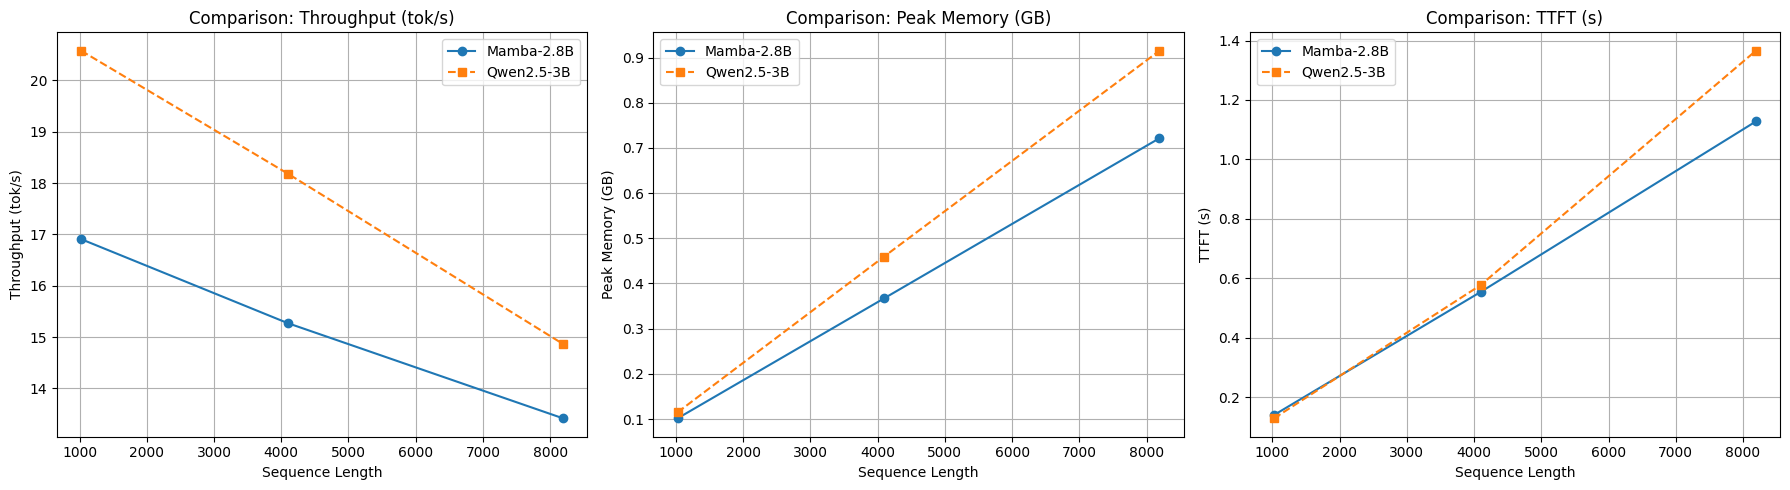

In [ ]:
def plot_results(mamba_data, transformer_data):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    lengths = sorted(mamba_data.keys())

    metrics = [('throughput', 'Throughput (tok/s)'), ('memory', 'Peak Memory (GB)'), ('ttft', 'TTFT (s)')]

    for i, (key, label) in enumerate(metrics):
        axes[i].plot(lengths, [mamba_data[l][key] for l in lengths], 'o-', label='Mamba-2.8B')
        qwen_lens = sorted(transformer_data.keys())
        axes[i].plot(qwen_lens, [transformer_data[l][key] for l in qwen_lens], 's--', label='Qwen2.5-3B')
        axes[i].set_xlabel('Sequence Length')
        axes[i].set_ylabel(label)
        axes[i].set_title(f'Comparison: {label}')
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

plot_results(res_mamba, res_qwen)